## Figure 3

The input files are available at [our repository on Zenodo](https://doi.org/10.5281/zenodo.19499423).

In [1]:
import os
import numpy as np
import pandas as pd

import SplIsoFind

from matplotlib import pyplot as plt
pd.options.mode.chained_assignment = None

/athena/tilgnerlab/scratch/lim4020/2022_08_15_PSIprediction/envs/SplIsoFind_016/lib/python3.9/site-packages/tqdm_joblib/__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


### Figure 3ahij - heatmaps 

In [2]:
allinfo = pd.read_csv('stereoseq_data_analysis/comb_AE_ONT/comb_ONT.UMI_filtered.ED4.allinfo_filtered.gz',
                      index_col=0, sep='\t', header=None)
allinfo.head()

,1,2,3,4,5,6,7,8,9,10,11,12
0,,,,,,,,,,,,
a8a93faf-10c6-4047-9859-f2a20e367bcd_11_1754_.,ENSMUSG00000051951.6,InhibNeuron_Midbrain,CCCTCCTTTACACAACTGTAACCCA,*,;%;chr1_3284667_3285485_.,NoTSS,NoPolyA,;%;chr1_3284213_3284666_.;%;chr1_3285486_32862...,novel,1,ENSMUST00000070533.5,unknown_type
40fcc40a-57a6-4c2b-8b8e-f8bd427b2d44_0_915_-,ENSMUSG00000051951.6,other_Midbrain,CATAAACCTTACTCAGGCCACGAGC,CGACGCAATC,;%;chr1_3285864_3286367_-,NoTSS,NoPolyA,;%;chr1_3285315_3285863_-;%;chr1_3286368_32866...,novel,1,NaN,NaN
a23ef04b-4170-4862-98f5-f3b9cda3deda_14_936_-,ENSMUSG00000051951.6,other_Midbrain,CATAAACCTTACTCAGGCCACGAGC,TCACTATTC,;%;chr1_3285852_3286360_.,NoTSS,NoPolyA,;%;chr1_3285313_3285851_.;%;chr1_3286361_32866...,novel,1,ENSMUST00000070533.5,unknown_type
f0409c63-1bf1-42de-89fa-f9d8e9a8de39_30_1791_+,ENSMUSG00000102331.2,other_Midbrain,CATCACATATATCTGACTAGGATGA,TCGTGTCTTG,;%;chr1_3719341_3732275_+,NoTSS,NoPolyA,;%;chr1_3718516_3719340_+;%;chr1_3732276_37322...,novel,1,NaN,NaN
ba375276-60e4-4f80-90d4-e5b65a93ae61_38_2121_+,ENSMUSG00000102331.2,ExciteNeuron_Thalamus,AACTAATTGATTAACCGACTGCTCC,ATTATCGCGC,;%;chr1_3720178_3739555_-;%;chr1_3739697_38741...,NoTSS,NoPolyA,;%;chr1_3718748_3720177_-;%;chr1_3739556_37396...,novel,2,ENSMUST00000192692.2,unknown_type


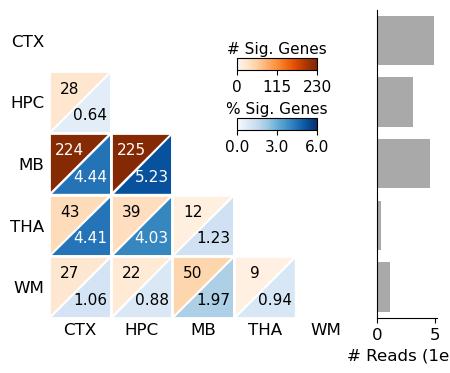

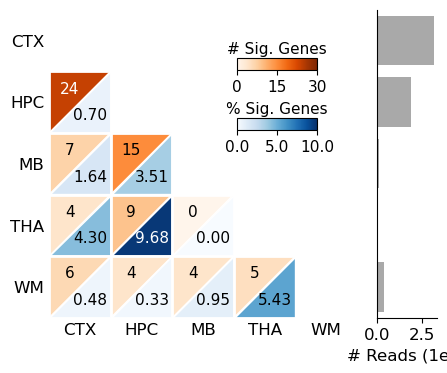

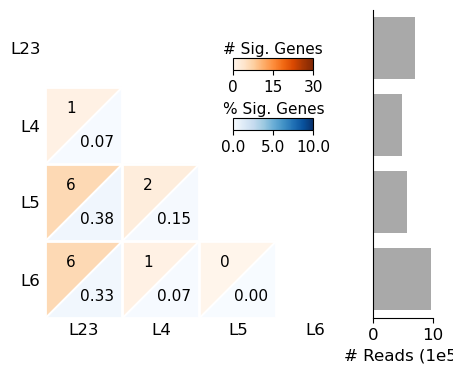

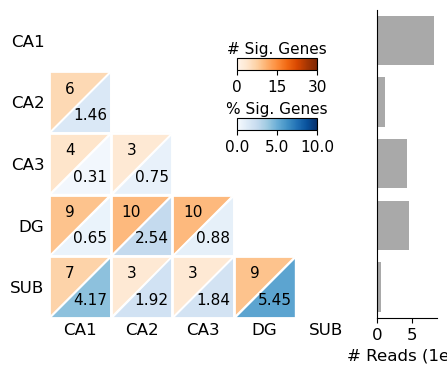

In [3]:
# Used to rename the regions in the plot
region_map = {
    'Cortex': 'CTX',
    'HPC': 'HPC',
    'Midbrain': 'MB',
    'Thalamus': 'THA',
    'WM': 'WM'
}

#Figure 3a
SplIsoFind.pl.plot_heatmap(input_dir='stereoseq_data_analysis/comb_AE_ONT/', 
             dataset='predefined_analysis', 
             region='All', 
             celltype='All', 
             allinfo=allinfo,
             region_map=region_map, region_map2=region_map)

#Figure 3h
SplIsoFind.pl.plot_heatmap(input_dir='stereoseq_data_analysis/comb_AE_ONT/', 
             dataset='predefined_analysis', 
             region='All', 
             celltype='ExciteNeuron', 
             allinfo=allinfo,
             region_map=region_map, region_map2=region_map,
             vmax_count=30, vmax_perc=10)

#Figure 3j
SplIsoFind.pl.plot_heatmap(input_dir='stereoseq_data_analysis/comb_AE_ONT/', 
             dataset='predefined_analysis', 
             region='cortex', 
             celltype='ExciteNeuron', 
             allinfo=allinfo,
             region_map=None, region_map2=None,
             vmax_count=30, vmax_perc=10)

region_map = {
    'CA1': 'CA1',
    'CA2': 'CA2',
    'CA3': 'CA3',
    'DG': 'DG',
    'Subiculum': 'SUB'
}

region_map2 = {
    'CA1_ML': 'CA1',
    'CA2': 'CA2',
    'CA3_ML': 'CA3',
    'DG_ML': 'DG',
    'Subiculum': 'SUB'
}

#Figure 3i
SplIsoFind.pl.plot_heatmap(input_dir='stereoseq_data_analysis/comb_AE_ONT/', 
             dataset='predefined_analysis', 
             region='HPC', 
             celltype='ExciteNeuron', 
             allinfo=allinfo,
             region_map=region_map, region_map2=region_map2,
             vmax_count=30, vmax_perc=10)


### Figure 3k - Gria2 example

In [4]:
from PIL import Image
Image.MAX_IMAGE_PIXELS = 553190400


In [5]:
dir_AE = 'stereoseq_data_analysis/comb_AE_ONT/isomatrix/'

x_AE, labels_AE, isoforms_AE = SplIsoFind.pp.load_sparse(input_dir = dir_AE)

# subset sample 1
labels_S1_AE = labels_AE[labels_AE['sample'] == 'S1']
x_S1_AE = x_AE[labels_AE['sample'] == 'S1']


In [6]:
im_reg_S1 = Image.open('tissue_staining/S1_ssDNA_regist.tif')
imarray_S1 = np.array(im_reg_S1)


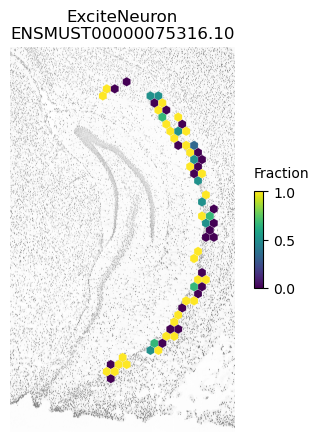

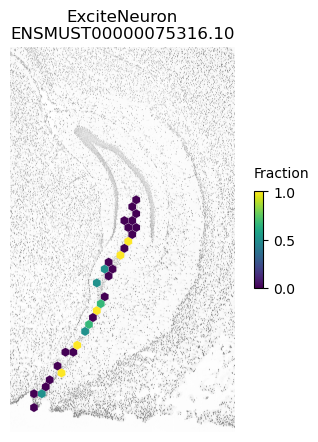

In [7]:
xlim1=8300
xlim2=14100
ylim1=4450
ylim2=14400

gria2_transcript = 'ENSMUST00000075316.10'

SplIsoFind.pl.spatial_hexplot_sparse(x_S1_AE[(labels_S1_AE['subregion'] == 'CA1_ML').values], 
                                     labels_S1_AE[labels_S1_AE['subregion']=='CA1_ML'], 
                                     isoforms_AE,
                                     varName=gria2_transcript, 
                                     imarray=imarray_S1,
                                     celltype='ExciteNeuron',
                                     hexsize=350, 
                                     plot_lim=[xlim1, xlim2, ylim1, ylim2])
plt.show()

SplIsoFind.pl.spatial_hexplot_sparse(x_S1_AE[(labels_S1_AE['subregion'] == 'CA3_ML').values], 
                                     labels_S1_AE[labels_S1_AE['subregion']=='CA3_ML'], 
                                     isoforms_AE,
                                     varName=gria2_transcript, 
                                     imarray=imarray_S1,
                                     celltype='ExciteNeuron',
                                     hexsize=350, 
                                     plot_lim=[xlim1, xlim2, ylim1, ylim2])
plt.show()

